In [1]:
from core.models.model_module_infer import model_module
inference_tester = model_module(
    data_dir='checkpoints/',
    pth=['CoDi_encoders.pth'],
    fp16=False
).cuda().eval()

net = inference_tester.net
print("✅ CoDi 编码器加载完成")


/home/liz0g/multi-dann-env/lib/python3.9/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)



#######################
# Running in eps mode #
#######################

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Load pretrained weight from ['CoDi_encoders.pth']
✅ CoDi 编码器加载完成


In [2]:
import torch
import torchaudio
import torchvision.transforms as T
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = inference_tester.net

def _l2n(x): return torch.nn.functional.normalize(x, dim=-1)


In [3]:
# 文本
def encode_text(list_of_str):
    with torch.no_grad():
        z = net.clip_encode_text(list_of_str).to(device)
        return _l2n(z)

# 图像
def encode_image(paths):
    outs = []
    tfm = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
    for p in paths:
        img = Image.open(p).convert('RGB')
        x = tfm(img).unsqueeze(0).to(device) * 2 - 1  # 归一化到 [-1,1]
        with torch.no_grad():
            f = net.clip_encode_vision(x)
            outs.append(_l2n(f))
    return torch.cat(outs, 0)

# 音频
def encode_audio(paths, target_sr=16000, seconds=10.0):
    outs = []
    T_len = int(target_sr * seconds)
    for p in paths:
        wav, sr = torchaudio.load(p)
        wav = wav.mean(0, keepdim=True)
        if sr != target_sr:
            wav = torchaudio.functional.resample(wav, sr, target_sr)
        if wav.size(-1) >= T_len:
            wav = wav[..., :T_len]
        else:
            wav = torch.nn.functional.pad(wav, (0, T_len - wav.size(-1)))
        wav = wav.unsqueeze(0).to(device)
        with torch.no_grad():
            f = net.clap_encode_audio(wav)
            outs.append(_l2n(f))
    return torch.cat(outs, 0)


[paths] BASE=/home/liz0g/semantic-communication/data  video=/home/liz0g/semantic-communication/data/vedio  image=/home/liz0g/semantic-communication/data/image  text=/home/liz0g/semantic-communication/data/text  audio=/home/liz0g/semantic-communication/data/audio
[gather] kabr_0068: tokens=77  images=33  audio_chunks=0
[gather] kabr_0068_trimmed: tokens=77  images=33  audio_chunks=204
[gather] kabr_0147: tokens=77  images=34  audio_chunks=0
[gather] kabr_0147_trimmed: tokens=77  images=34  audio_chunks=211
[gather] kabr_DJI_0068: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0069: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0070: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0071: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0142: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0143: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0144: tokens=0  images=0  audio_chunks=0
[gather] kabr_DJI_0145: tokens=0  images=0  audio_chunks=0
[dim] CLIP_D=1  T

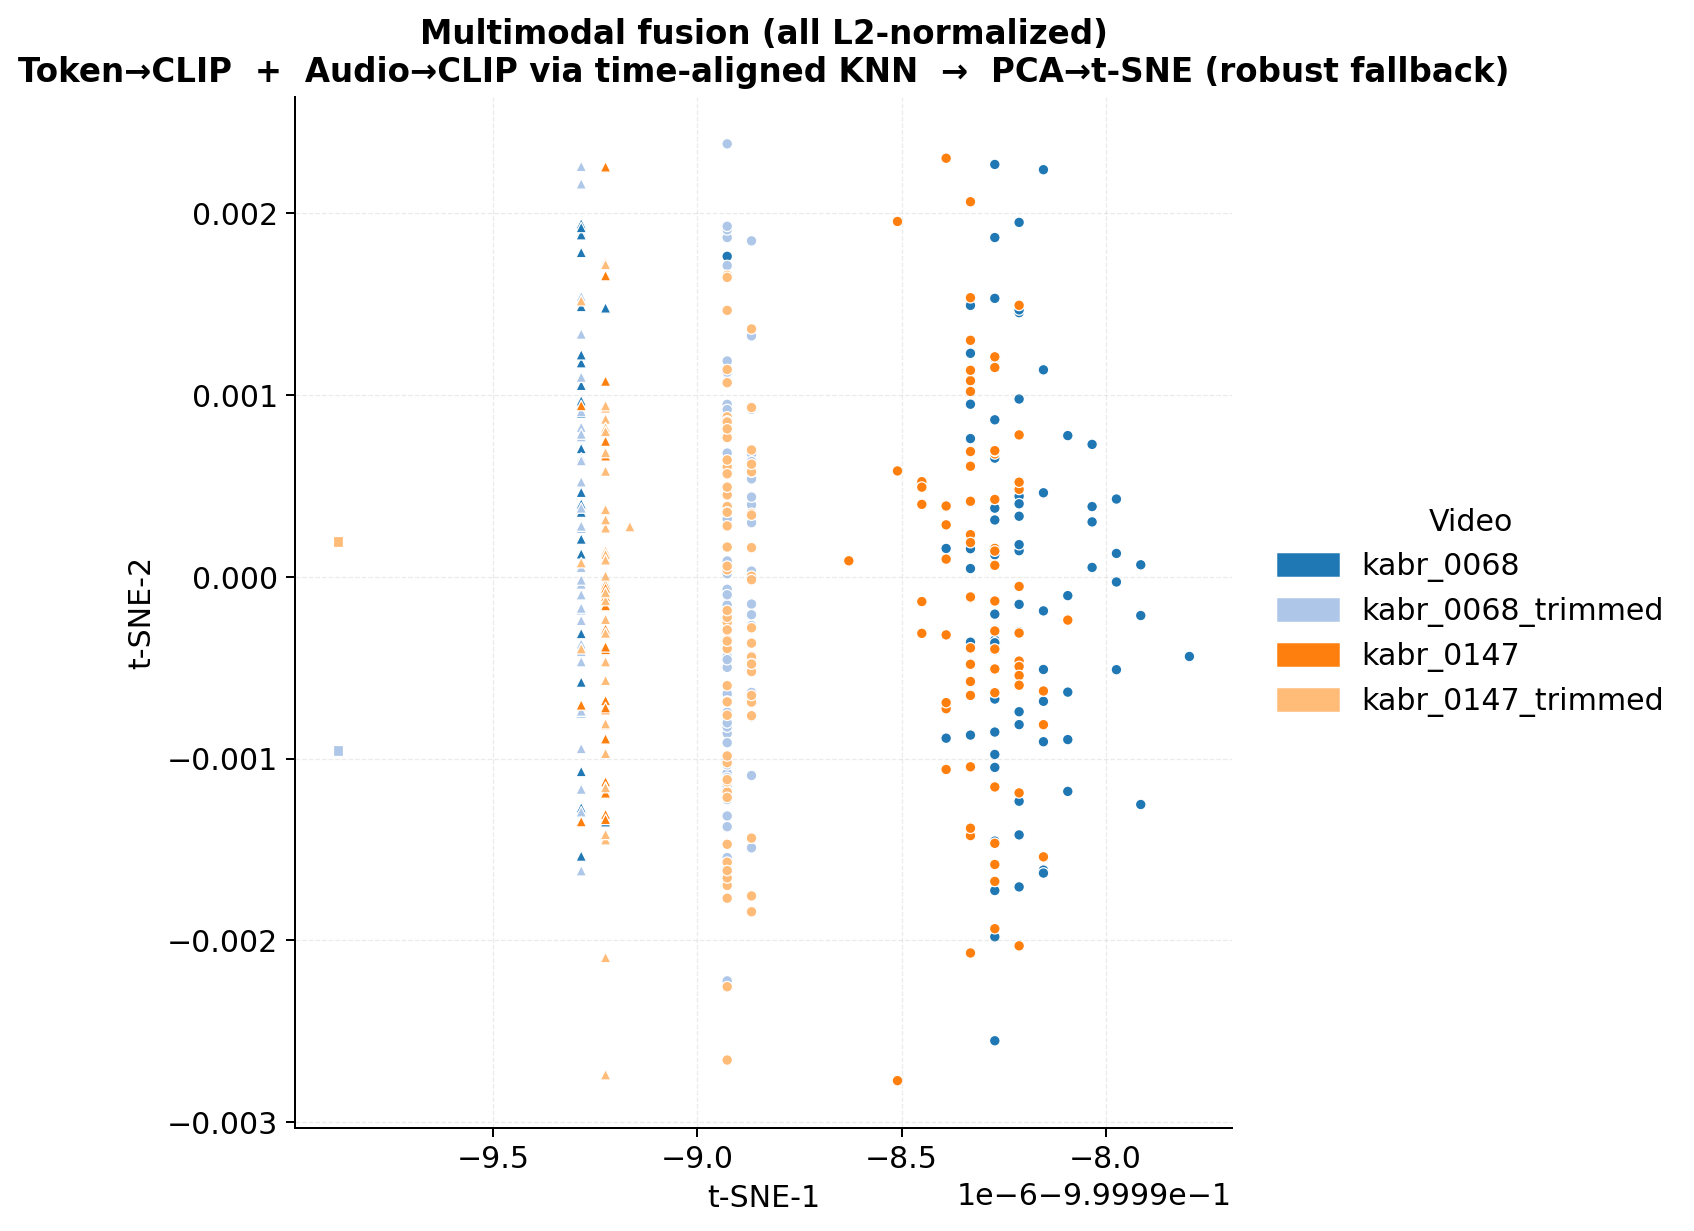

In [17]:
# ================== Multimodal fusion t-SNE (all L2, shape-safe, robust fallback) ==================
# Token -> CLIP (learn W_tok) + Audio -> CLIP (time-aligned KNN frames, learn W_aud)
# ../data 与 i-Code-V3 同级；颜色=视频ID，形状=模态。N 太少时自动回退 2D 直投影。

import os, re, glob, numpy as np, torch
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
import torchaudio

# ---- model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = net.to(device).eval()   # 你的 encoder: net = inference_tester.net

# ---- paths ----
_BASE = Path("../data").resolve()
if not _BASE.exists(): raise FileNotFoundError(f"没找到 ../data；当前：{Path.cwd()}")
_DVID = next((p for p in (_BASE/"vedio", _BASE/"video") if p.exists()), None)
if _DVID is None: raise FileNotFoundError(f"在 {_BASE} 下没找到 vedio/ 或 video/")
DVID, DIMG, DTXT, DAUD = str(_DVID), str(_BASE/"image"), str(_BASE/"text"), str(_BASE/"audio")
print(f"[paths] BASE={_BASE}  video={DVID}  image={DIMG}  text={DTXT}  audio={DAUD}")

# ---------------- utils ----------------
def _l2n(x: torch.Tensor):
    return torch.nn.functional.normalize(x, dim=-1)

def l2n_np(X: np.ndarray) -> np.ndarray:
    """1D/2D 都支持：1D -> overall；2D -> row-wise。"""
    X = np.asarray(X, dtype=np.float32)
    if X.size == 0: return X
    if X.ndim == 1:
        nrm = float(np.linalg.norm(X) + 1e-8)
        return X / nrm
    nrm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    return X / nrm

def clean_srt_text(t: str) -> str:
    t = re.sub(r"\d+\s*\n", " ", t)
    t = re.sub(r"\d{2}:\d{2}:\d{2},\d{3}\s*-->\s*\d{2}:\d{2}:\d{2},\d{3}", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def read_text_by_stem(stem: str) -> str:
    for ext in (".txt", ".srt"):
        p = os.path.join(DTXT, stem+ext)
        if os.path.isfile(p):
            return clean_srt_text(open(p,"r",encoding="utf-8",errors="ignore").read())
    return ""

def stem_from_path(p):
    b = os.path.basename(p)
    if b.endswith(".jpg"):
        m = re.match(r"(.+?)_\d{4}\.jpg$", b)
        return m.group(1) if m else os.path.splitext(b)[0]
    return os.path.splitext(b)[0]

def ensure_2d(A: np.ndarray) -> np.ndarray:
    """压到二维 [N,D]（保留最后一维为通道；会展平其它维度）。"""
    A = np.asarray(A)
    if A.ndim == 1: return A[None, :]
    if A.ndim == 2: return A
    return A.reshape(-1, A.shape[-1])

def to_dim(A: np.ndarray, D: int) -> np.ndarray:
    """若是 [N,L,D] 先取 CLS，再 pad/截断到 [N,D]。"""
    A = np.asarray(A)
    if A.ndim == 3: A = A[:,0,:]
    else: A = ensure_2d(A)
    n,d = A.shape
    if d==D: return A
    if d < D: return np.concatenate([A, np.zeros((n, D-d), A.dtype)], 1)
    return A[:, :D]

def as_vec(x, D: int) -> np.ndarray:
    """把任意形状变成一维 [D]（pad/截断）。"""
    a = np.asarray(x)
    if a.size == 0: return np.zeros((D,), np.float32)
    if a.ndim == 1:
        if a.shape[0] == D: return a.astype(np.float32)
        if a.shape[0] < D: return np.concatenate([a, np.zeros((D-a.shape[0],), a.dtype)], 0).astype(np.float32)
        return a[:D].astype(np.float32)
    return to_dim(a, D)[0].astype(np.float32)

# ---------------- text: token (hook) + sentence embed ----------------
def extract_text_tokens_and_sentence(net, texts):
    captured_ids, captured_seq = [], []

    emb_hook = None
    for name, m in net.named_modules():
        if isinstance(m, torch.nn.Embedding):
            def _eh(module, inputs, output):
                try:
                    x = inputs[0]
                    if torch.is_tensor(x) and x.ndim == 2:
                        captured_ids.append(x.detach().cpu())
                except: pass
            emb_hook = m.register_forward_hook(_eh)
            break

    tr_hooks = []
    for name, m in net.named_modules():
        lname = name.lower()
        if any(k in lname for k in ["text","transformer","clip"]) and not any(k in lname for k in ["vision","image","vit"]):
            def _th(module, inputs, output):
                h = output[0] if isinstance(output,(tuple,list)) else output
                if torch.is_tensor(h) and h.ndim == 3:
                    captured_seq.append(h.detach().cpu())
            tr_hooks.append(m.register_forward_hook(_th))

    with torch.no_grad():
        sent = net.clip_encode_text(texts)    # [B, Dclip]
        sent = _l2n(sent).detach().cpu().numpy()
    if emb_hook is not None: emb_hook.remove()
    for h in tr_hooks: h.remove()

    if not captured_seq: raise RuntimeError("没抓到 token 序列表示")
    H = _l2n(captured_seq[-1]).cpu().numpy()  # [B,L,Dtok]（已 L2）
    ids = captured_ids[-1] if captured_ids else None

    E_list = []
    for i in range(H.shape[0]):
        valid = list(range(H.shape[1]))
        if ids is not None:
            row = ids[i].tolist()
            last = max([j for j,t in enumerate(row) if t!=0], default=-1)
            if last >= 0: valid = list(range(last+1))
        if valid: E_list.append(H[i, valid])          # [Li, Dtok]
    E = np.concatenate(E_list, 0).astype(np.float32) if E_list else np.zeros((0,H.shape[-1]), np.float32)
    return l2n_np(E), sent   # token states (2D, L2), sentence embed (2D, L2)

# ---------------- image: per-frame (CLS) ----------------
_TFM = T.Compose([T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
                  T.CenterCrop(224), T.ToTensor()])
def encode_images(paths):
    outs, Dg = [], None
    for p in paths:
        img = Image.open(p).convert("RGB")
        x = _TFM(img).unsqueeze(0).to(device)*2 - 1
        with torch.no_grad():
            f = net.clip_encode_vision(x)   # [1,D] or [1,L,D]
        f = _l2n(f).detach().cpu().numpy()
        if f.ndim == 3: f = f[:,0,:]
        elif f.ndim > 2: f = f.reshape(-1, f.shape[-1])
        outs.append(f); Dg = f.shape[-1]
    if not outs: return np.zeros((0, Dg if Dg else 512), np.float32)
    return l2n_np(np.concatenate(outs, 0).astype(np.float32))  # [N,D], L2

# ---------------- audio: chunked (no mean) ----------------
def encode_audio_chunks(path, target_sr=16000, chunk_sec=1.6, hop_sec=0.8):
    if not os.path.isfile(path): return np.zeros((0, 768), np.float32)
    wav, sr = torchaudio.load(path); wav = wav.mean(0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr); sr = target_sr
    L = int(sr*chunk_sec); H = int(sr*hop_sec)
    outs, Dg = [], None
    with torch.no_grad():
        for s in range(0, max(1, wav.size(-1)-L+1), H):
            x = wav[..., s:s+L]
            if x.size(-1) < L: x = torch.nn.functional.pad(x, (0, L-x.size(-1)))
            x = x.unsqueeze(0).to(device)  # [1,1,L]
            f = net.clap_encode_audio(x)
            if f.ndim == 1: f = f.unsqueeze(0)
            f = _l2n(f).detach().cpu().numpy()
            if f.ndim == 3: f = f[:,0,:]
            elif f.ndim > 2: f = f.reshape(-1, f.shape[-1])
            outs.append(f); Dg = f.shape[-1]
    if not outs: return np.zeros((0, Dg if Dg else 768), np.float32)
    return l2n_np(np.concatenate(outs, 0).astype(np.float32))  # [N,Da], L2

# ---------------- gather ----------------
def gather_by_video():
    stems=set()
    for p in glob.glob(os.path.join(DVID,"*.mp4")): stems.add(stem_from_path(p))
    for p in glob.glob(os.path.join(DIMG,"*.jpg")):
        s = stem_from_path(p); 
        if s: stems.add(s)
    for p in glob.glob(os.path.join(DTXT,"*.txt"))+glob.glob(os.path.join(DTXT,"*.srt")): stems.add(stem_from_path(p))
    for p in glob.glob(os.path.join(DAUD,"*.wav")): stems.add(stem_from_path(p))
    stems=sorted(stems)

    out={}
    for s in stems:
        txt = read_text_by_stem(s)
        if txt:
            Etok, Ssent = extract_text_tokens_and_sentence(net, [txt])  # [Ntok,Dtok](L2), [1,Dclip](L2)
        else:
            Etok = np.zeros((0,512), np.float32); Ssent = np.zeros((1,512), np.float32)
        frames = sorted(glob.glob(os.path.join(DIMG, f"{s}_*.jpg")))
        Eimg = encode_images(frames) if frames else np.zeros((0, Ssent.shape[1] if Ssent.size else 512), np.float32)
        wavp = os.path.join(DAUD, f"{s}.wav")
        Eaud = encode_audio_chunks(wavp) if os.path.isfile(wavp) else np.zeros((0, 768), np.float32)
        out[s] = {"text_tok": Etok, "sent": Ssent, "image": Eimg, "audio": Eaud, "n_frames": len(frames)}
        print(f"[gather] {s}: tokens={len(Etok)}  images={len(Eimg)}  audio_chunks={len(Eaud)}")
    return out

data = gather_by_video()

# ---------------- dims ----------------
CLIP_D = next((v["sent"].shape[1] for v in data.values() if v["sent"].size), None)
if CLIP_D is None:
    CLIP_D = next((v["image"].shape[1] for v in data.values() if v["image"].size), None)
if CLIP_D is None: raise RuntimeError("无法确定 CLIP 维度")
TEXT_D = next((v["text_tok"].shape[1] for v in data.values() if v["text_tok"].size), None)
AUDIO_D = next((v["audio"].shape[1] for v in data.values() if v["audio"].size), None)
print(f"[dim] CLIP_D={CLIP_D}  TEXT_D={TEXT_D}  AUDIO_D={AUDIO_D}")

# ================== STEP 1: token -> CLIP (learn W_tok) ==================
H_all, S_all = [], []
for v in data.values():
    if v["text_tok"].size and v["sent"].size:
        H = ensure_2d(v["text_tok"]).astype(np.float32)
        s = ensure_2d(v["sent"][:1]).astype(np.float32)      # [1, Dclip]
        S = np.repeat(s, H.shape[0], axis=0)                  # [Ntok, Dclip]
        H_all.append(H); S_all.append(S)
if H_all:
    H = ensure_2d(np.vstack(H_all)).astype(np.float32)
    S = ensure_2d(np.vstack(S_all)).astype(np.float32)
    W_tok = Ridge(alpha=1.0, fit_intercept=False).fit(H, S).coef_.T  # [Dtok, Dclip]
else:
    W_tok = None

for k, v in data.items():
    if W_tok is not None and v["text_tok"].size:
        data[k]["text_clip"] = l2n_np(ensure_2d(v["text_tok"]) @ W_tok)
    else:
        data[k]["text_clip"] = np.zeros((0, CLIP_D), np.float32)

# ================== STEP 2: audio -> CLIP (time-aligned KNN, learn W_aud) ==================
K = 3
A_pairs, T_pairs, vid_a = [], [], []
for gid, v in data.items():
    Ea = v["audio"]; Ei = v["image"]; Etc = v["text_clip"]; Ss = v["sent"]
    if not Ea.size: continue
    Nf = len(Ei); Ma = len(Ea)
    for m in range(Ma):
        vecs = []
        if Nf > 0:
            idx = int(round(m * (max(Nf-1,0) / max(Ma-1,1))))
            neigh = [max(0, min(Nf-1, idx + d)) for d in range(-K//2, K//2+1)]
            for i in neigh:
                vecs.append(as_vec(Ei[i], CLIP_D))
        if Ss.size:
            vecs.append(as_vec(Ss[0], CLIP_D))
        if Etc.size:
            vecs.append(as_vec(Etc[min(m, len(Etc)-1)], CLIP_D))
        tgt_vec = np.mean(np.stack(vecs, axis=0), axis=0) if len(vecs) else as_vec(Ss[0] if Ss.size else np.zeros((CLIP_D,), np.float32), CLIP_D)
        A_pairs.append(Ea[m:m+1])
        T_pairs.append(tgt_vec[None,:]); vid_a.append(gid)

if A_pairs:
    A = ensure_2d(np.vstack(A_pairs)).astype(np.float32)
    T = ensure_2d(np.vstack(T_pairs)).astype(np.float32)
    Wa = Ridge(alpha=1.0, fit_intercept=False).fit(A, T).coef_.T   # [Da, Dclip]
    for gid, v in data.items():
        if v["audio"].size:
            mapped = ensure_2d(v["audio"]) @ Wa
            data[gid]["audio_clip"] = l2n_np(mapped)
        else:
            data[gid]["audio_clip"] = np.zeros((0, CLIP_D), np.float32)
else:
    for gid, v in data.items():
        data[gid]["audio_clip"] = np.zeros((0, CLIP_D), np.float32)

# ================== Stack (to_dim + L2) ==================
rows, vids, mods = [], [], []
for gid, v in data.items():
    if v["text_clip"].size:
        R = l2n_np(to_dim(v["text_clip"], CLIP_D))
        rows.append(R); vids += [gid]*len(R); mods += ["text_token"]*len(R)
    if v["image"].size:
        R = l2n_np(to_dim(v["image"], CLIP_D))
        rows.append(R); vids += [gid]*len(R); mods += ["image"]*len(R)
    if v["audio_clip"].size:
        R = l2n_np(to_dim(v["audio_clip"], CLIP_D))
        rows.append(R); vids += [gid]*len(R); mods += ["audio*"]*len(R)

if not rows: raise RuntimeError("没有可视化样本。")

X = np.vstack(rows).astype(np.float32)  # [N,D]
N, D = X.shape
print(f"[counts] N={N}  text_token={mods.count('text_token')}  image={mods.count('image')}  audio*={mods.count('audio*')}")

# ================== PCA/TSNE with robust fallback ==================
if N < 3 or D < 2:
    # 无法做 PCA/TSNE：直接取前两维可视化（不足两维则补 0 并加微抖动）
    print(f"[warn] too few samples/features for PCA/t-SNE (N={N}, D={D}); using direct 2D fallback.")
    Y = np.zeros((N, 2), dtype=np.float32)
    if D >= 1: Y[:,0] = X[:,0]
    if D >= 2: Y[:,1] = X[:,1]
    if D < 2:
        rng = np.random.RandomState(0)
        Y[:,1] = Y[:,1] + rng.normal(scale=1e-3, size=N)
else:
    n_pca = min(50, D, N-1)
    n_pca = max(2, n_pca)
    X50 = PCA(n_components=n_pca, random_state=0).fit_transform(X)
    X50 = l2n_np(X50)
    perp = min(30, max(2, N-1))   # t-SNE 要求 perplexity < N
    Y = TSNE(n_components=2, perplexity=perp, init="pca",
             learning_rate="auto", n_iter=2000, random_state=0).fit_transform(X50)

# ---------------- plot ----------------
uniq_vids = list(dict.fromkeys(vids))
cmap = plt.get_cmap("tab20")
colors = [cmap(uniq_vids.index(v)%20) for v in vids]
marker_map = {"text_token":"o", "image":"^", "audio*":"s"}

plt.figure(figsize=(9,7))
for m in ["text_token","image","audio*"]:
    idx = [i for i,mm in enumerate(mods) if mm==m]
    if not idx: continue
    plt.scatter(Y[idx,0], Y[idx,1], s=18, marker=marker_map[m],
                edgecolors="white", linewidths=0.5, c=[colors[i] for i in idx], label=m)

import matplotlib.patches as mpatches
handles=[mpatches.Patch(color=cmap(i%20), label=g) for i,g in enumerate(uniq_vids)]
plt.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02,0.5), title="Video")
plt.title("Multimodal fusion (all L2-normalized)\nToken→CLIP  +  Audio→CLIP via time-aligned KNN  →  PCA→t-SNE (robust fallback)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.grid(True, ls="--", lw=0.5, alpha=0.25)
plt.gca().spines["top"].set_visible(False); plt.gca().spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


In [24]:
# ========================= Multimodal alignment training (robust dims) =========================
# 冻结编码器，训练两个轻量线性映射，把同视频（同色）的跨模态 token/帧/音频拉近
# Loss = Supervised Contrastive + Prototype pull + L2
# 这版修复了 CLIP_D 错推为 1 的问题，并在采样时对齐所有特征到同一维度

import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path
from typing import Dict

assert 'net' in globals(), "缺少 net（inference_tester.net）。请先运行加载编码器的 cell。"
assert 'data' in globals(), "缺少 data 字典（含 text_tok/image/audio/sent）。请先运行数据采集的 cell。"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = net.to(device).eval()
torch.set_grad_enabled(True)

# ---------- utils ----------
def l2n_t(x): return F.normalize(x, dim=-1)

def ensure_2d_t(t: torch.Tensor) -> torch.Tensor:
    if t.dim() == 1:  return t.unsqueeze(0)
    if t.dim() == 2:  return t
    return t.reshape(t.size(0), -1)

def to_dim_t(t: torch.Tensor, D: int) -> torch.Tensor:
    """把最后一维 pad/截断到 D，输入允许是 [N,D?] 或 [D?]"""
    t = ensure_2d_t(t)
    n, d = t.shape
    if d == D: return t
    if d < D:
        pad = t.new_zeros(n, D - d)
        return torch.cat([t, pad], dim=1)
    return t[:, :D]

@torch.no_grad()
def infer_dims_from_data_robust(d: Dict):
    """更稳健的维度推断：优先取 image 的维度（多数/最大），再回退 sent 的合理维度（>1）。"""
    img_dims = []
    sent_dims = []
    for v in d.values():
        if v.get("image", None) is not None and v["image"].size:
            img_dims.append(int(v["image"].shape[1]))
        if v.get("sent", None) is not None and v["sent"].size:
            sd = int(v["sent"].shape[1])
            if sd > 1:  # 屏蔽 (1,1) 这种异常占位
                sent_dims.append(sd)
    # CLIP_D 选择逻辑：优先 image（稳定），否则取 sent 中 >1 的最大值，再不行默认 768
    if img_dims:
        # 选出现次数最多的维度；若并列，取最大
        from collections import Counter
        cnt = Counter(img_dims)
        max_freq = max(cnt.values())
        candidates = [k for k,v in cnt.items() if v == max_freq]
        CLIP_D = max(candidates)
    elif sent_dims:
        CLIP_D = max(sent_dims)
    else:
        CLIP_D = 768  # 安全默认值
    # 其他模态输入维
    TEXT_D = next((int(v["text_tok"].shape[1]) for v in d.values()
                   if v.get("text_tok", None) is not None and v["text_tok"].size), None)
    AUDIO_D = next((int(v["audio"].shape[1]) for v in d.values()
                    if v.get("audio", None) is not None and v["audio"].size), None)
    return int(CLIP_D), TEXT_D, AUDIO_D

CLIP_D, TEXT_D, AUDIO_D = infer_dims_from_data_robust(data)
print(f"[dims] CLIP_D={CLIP_D}  TEXT_D={TEXT_D}  AUDIO_D={AUDIO_D}")

# ---------- losses ----------
def supervised_contrastive_loss(z, y, temperature=0.07):
    z = l2n_t(z)
    sim = z @ z.t() / temperature
    N = z.size(0)
    ycol = y.view(-1, 1)
    mask_pos = (ycol == ycol.t()) & (~torch.eye(N, dtype=torch.bool, device=z.device))
    logits = sim - torch.eye(N, device=z.device) * 1e9
    log_prob = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    pos_cnt = mask_pos.float().sum(1).clamp_min(1.0)
    mean_log_prob_pos = (log_prob * mask_pos.float()).sum(1) / pos_cnt
    return -mean_log_prob_pos.mean()

def prototype_pull_loss(z, y, detach_proto=True):
    z = l2n_t(z)
    loss_items = []
    for vid in y.unique():
        idx = (y == vid)
        if idx.sum() <= 1: 
            continue
        c = z[idx].mean(0, keepdim=True)
        if detach_proto: c = c.detach()
        loss_items.append(((z[idx] - c)**2).sum(-1).mean())
    return torch.stack(loss_items).mean() if loss_items else z.new_tensor(0.0)

# ---------- mappers ----------
class Mapper(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out, bias=False)
        nn.init.xavier_uniform_(self.lin.weight)
    def forward(self, x):
        x = ensure_2d_t(x)
        x = self.lin(x)
        return l2n_t(x)

mapper_tok = Mapper(TEXT_D, CLIP_D).to(device) if TEXT_D else None
mapper_aud = Mapper(AUDIO_D, CLIP_D).to(device) if AUDIO_D else None

# （可选）用你之前的岭回归权重热启动
# with torch.no_grad():
#     if 'W_tok' in globals() and mapper_tok is not None:
#         mapper_tok.lin.weight.copy_(torch.from_numpy(W_tok.T))
#     if 'Wa'    in globals() and mapper_aud is not None:
#         mapper_aud.lin.weight.copy_(torch.from_numpy(Wa.T))

# ---------- batch sampler（采样时强制对齐到 CLIP_D） ----------
import numpy.random as npr

def sample_batch(d: Dict, per_vid_tokens=64, per_vid_images=12, per_vid_audio=48):
    vids = list(d.keys())
    z_chunks, y_chunks = [], []
    used_vids = 0
    for vid_id, k in enumerate(vids):
        v = d[k]
        used = False

        # text tokens -> mapper_tok -> [n, CLIP_D]
        if mapper_tok is not None and v.get("text_tok", None) is not None and v["text_tok"].size:
            n = min(per_vid_tokens, len(v["text_tok"]))
            idx = npr.choice(len(v["text_tok"]), size=n, replace=False)
            zt = torch.from_numpy(v["text_tok"][idx]).float().to(device)
            zt = mapper_tok(zt)                               # [n, CLIP_D]
            z_chunks.append(zt); y_chunks.append(torch.full((n,), vid_id, dtype=torch.long, device=device))
            used = True

        # images -> 直接对齐到 CLIP_D 再 L2
        if v.get("image", None) is not None and v["image"].size:
            n = min(per_vid_images, len(v["image"]))
            idx = npr.choice(len(v["image"]), size=n, replace=False)
            zi = torch.from_numpy(v["image"][idx]).float().to(device)
            zi = to_dim_t(zi, CLIP_D)
            zi = l2n_t(zi)
            z_chunks.append(zi); y_chunks.append(torch.full((n,), vid_id, dtype=torch.long, device=device))
            used = True

        # audio chunks -> mapper_aud -> [n, CLIP_D]
        if mapper_aud is not None and v.get("audio", None) is not None and v["audio"].size:
            n = min(per_vid_audio, len(v["audio"]))
            idx = npr.choice(len(v["audio"]), size=n, replace=False)
            za = torch.from_numpy(v["audio"][idx]).float().to(device)
            za = mapper_aud(za)                               # [n, CLIP_D]
            z_chunks.append(za); y_chunks.append(torch.full((n,), vid_id, dtype=torch.long, device=device))
            used = True

        if used: used_vids += 1

    if not z_chunks or used_vids < 2:
        return None, None

    # 最终安全检查（不会再出现 {768,1}）
    Dset = {zc.size(-1) for zc in z_chunks}
    if len(Dset) != 1:
        shapes = [tuple(zc.shape) for zc in z_chunks]
        raise RuntimeError(f"特征维不一致: {Dset}, shapes={shapes}")

    z_all = torch.cat(z_chunks, 0)                            # [N, CLIP_D]
    y_all = torch.cat(y_chunks, 0)                            # [N]
    return z_all, y_all

# ---------- optimizer & schedule ----------
params = []
if mapper_tok is not None: params += list(mapper_tok.parameters())
if mapper_aud is not None: params += list(mapper_aud.parameters())
assert params, "没有可训练的映射层（TEXT_D/AUDIO_D 都为空？）"

opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-6)

# ---------- train ----------
steps        = 500
tau          = 0.07
w_proto      = 0.5
w_l2         = 1e-4
tokens_per_v = 64
imgs_per_v   = 12
aud_per_v    = 48

net.requires_grad_(False)
for step in range(1, steps+1):
    samp = sample_batch(data, tokens_per_v, imgs_per_v, aud_per_v)
    if samp == (None, None):
        continue
    z_all, y_all = samp
    L_con  = supervised_contrastive_loss(z_all, y_all, temperature=tau)
    L_prot = prototype_pull_loss(z_all, y_all, detach_proto=True)
    L_reg  = w_l2 * sum((p**2).sum() for p in params)
    loss   = L_con + w_proto * L_prot + L_reg

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 50 == 0:
        with torch.no_grad():
            z = l2n_t(z_all)
            y = y_all
            same = (y[:,None] == y[None,:]).float()
            diff = 1.0 - same
            d2 = ((z[:,None,:] - z[None,:,:])**2).sum(-1)
            same_mask = same - torch.eye(len(y), device=z.device)
            intra = (d2 * same_mask).sum() / same_mask.sum().clamp_min(1)
            inter = (d2 * diff).sum() / diff.sum().clamp_min(1)
        print(f"step {step:04d} | loss={loss.item():.4f}  (con={L_con.item():.4f}, proto={L_prot.item():.4f})  "
              f"| intra={float(intra):.4f}  inter={float(inter):.4f}")

# ---------- save ----------
outdir = Path("./runs"); outdir.mkdir(parents=True, exist_ok=True)
if mapper_tok is not None:
    torch.save({'state_dict': mapper_tok.state_dict(), 'in_dim': int(TEXT_D), 'out_dim': int(CLIP_D)}, outdir/"align_mapper_tok.pt")
if mapper_aud is not None:
    torch.save({'state_dict': mapper_aud.state_dict(), 'in_dim': int(AUDIO_D), 'out_dim': int(CLIP_D)}, outdir/"align_mapper_aud.pt")
print("✅ Saved:", [p.name for p in outdir.glob("align_mapper_*.pt")])

# 用法提示（可视化时）：
# text_clip  = mapper_tok(torch.from_numpy(text_tok_np).float().to(device))
# audio_clip = mapper_aud(torch.from_numpy(audio_np).float().to(device))
# image_clip = l2n_t(to_dim_t(torch.from_numpy(image_np).float().to(device), CLIP_D))
# 三者 .cpu().numpy() 后堆一起做 PCA→t-SNE。


[dims] CLIP_D=768  TEXT_D=768  AUDIO_D=768
step 0050 | loss=6.1020  (con=5.9069, proto=0.0908)  | intra=0.1575  inter=0.4158
step 0100 | loss=5.7421  (con=5.5822, proto=0.0547)  | intra=0.0886  inter=0.3479
step 0150 | loss=5.6930  (con=5.5557, proto=0.0385)  | intra=0.0644  inter=0.3282
step 0200 | loss=5.6561  (con=5.5362, proto=0.0295)  | intra=0.0510  inter=0.3149
step 0250 | loss=5.6302  (con=5.5237, proto=0.0254)  | intra=0.0443  inter=0.3136
step 0300 | loss=5.6116  (con=5.5163, proto=0.0229)  | intra=0.0398  inter=0.3077
step 0350 | loss=5.5998  (con=5.5136, proto=0.0222)  | intra=0.0396  inter=0.3085
step 0400 | loss=5.5870  (con=5.5087, proto=0.0217)  | intra=0.0372  inter=0.3066
step 0450 | loss=5.5833  (con=5.5117, proto=0.0222)  | intra=0.0388  inter=0.3077
step 0500 | loss=5.5758  (con=5.5101, proto=0.0223)  | intra=0.0381  inter=0.3058
✅ Saved: ['align_mapper_tok.pt', 'align_mapper_aud.pt']


[dims] CLIP_D=768  TEXT_D=768  AUDIO_D=768
✅ loaded align_mapper_tok.pt
✅ loaded align_mapper_aud.pt
[counts] N=857  text_token=308  image=134  audio*=415


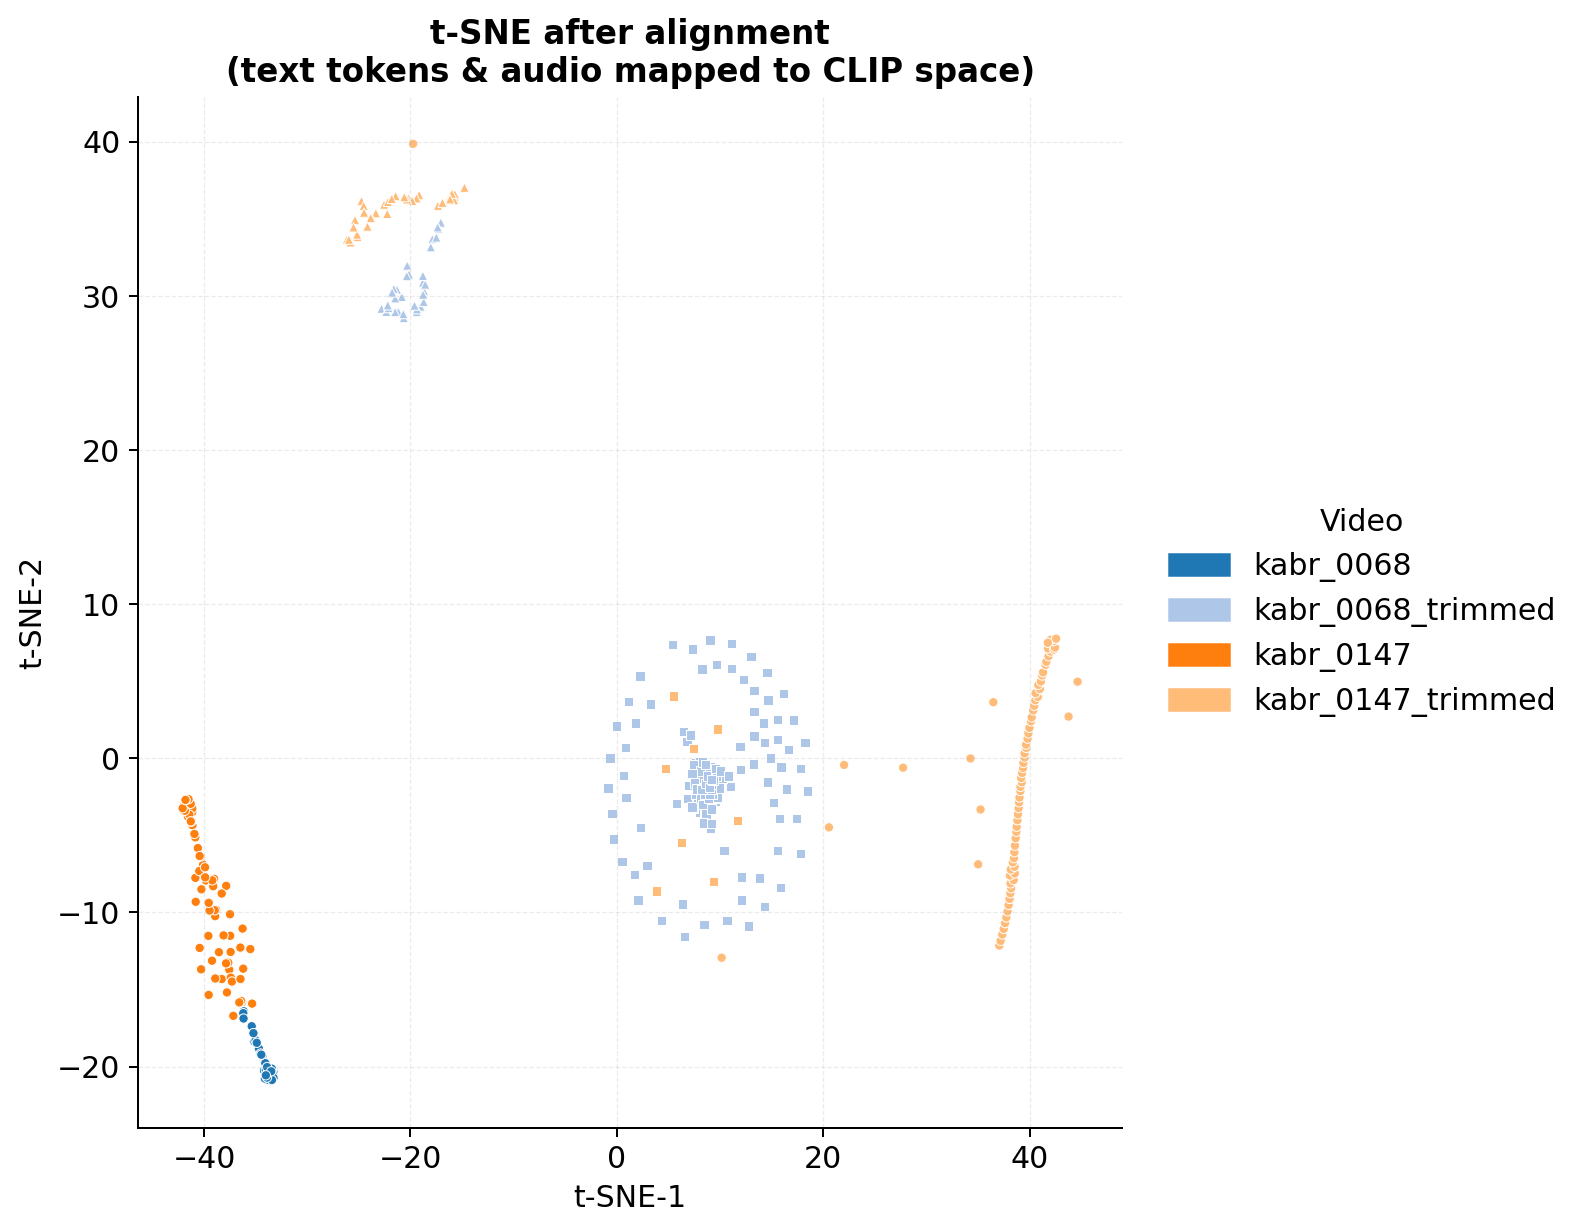

✅ Saved tsne_aligned.png / tsne_aligned.pdf


In [25]:
# ========================= Visualize after alignment (run-this-cell) =========================
# 用保存的映射层把 text_token / audio 映射到 CLIP 维度，与 image 一起做 PCA→t-SNE 并绘图
import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

assert 'data' in globals(), "缺少 data（上一阶段的数据采集产物）。"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def l2n_np(X):
    X = np.asarray(X, dtype=np.float32)
    if X.size == 0: return X
    if X.ndim == 1:
        nrm = float(np.linalg.norm(X) + 1e-8); return X / nrm
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

def ensure_2d_np(A):
    A = np.asarray(A)
    if A.ndim == 1: return A[None,:]
    if A.ndim == 2: return A
    return A.reshape(-1, A.shape[-1])

def to_dim_np(A, D):
    A = ensure_2d_np(A)
    n,d = A.shape
    if d==D: return A
    if d < D: return np.concatenate([A, np.zeros((n, D-d), A.dtype)], 1)
    return A[:, :D]

# ---- 维度推断（和训练时一致） ----
from collections import Counter
img_dims, sent_dims = [], []
for v in data.values():
    if v.get("image") is not None and v["image"].size: img_dims.append(int(v["image"].shape[1]))
    if v.get("sent")  is not None and v["sent"].size and v["sent"].shape[1] > 1: sent_dims.append(int(v["sent"].shape[1]))
if img_dims:
    cnt = Counter(img_dims); m = max(cnt.values()); CLIP_D = max([k for k,v in cnt.items() if v==m])
elif sent_dims:
    CLIP_D = max(sent_dims)
else:
    CLIP_D = 768
TEXT_D = next((int(v["text_tok"].shape[1]) for v in data.values() if v.get("text_tok") is not None and v["text_tok"].size), None)
AUDIO_D = next((int(v["audio"].shape[1])    for v in data.values() if v.get("audio")    is not None and v["audio"].size), None)
print(f"[dims] CLIP_D={CLIP_D}  TEXT_D={TEXT_D}  AUDIO_D={AUDIO_D}")

# ---- 定义并加载映射器 ----
class Mapper(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out, bias=False)
    def forward(self, x):
        x = torch.as_tensor(x, dtype=torch.float32, device=device)
        if x.ndim == 1: x = x.unsqueeze(0)
        x = self.lin(x)
        x = torch.nn.functional.normalize(x, dim=-1)
        return x

mapper_tok, mapper_aud = None, None
tok_ckpt = Path("./runs/align_mapper_tok.pt")
aud_ckpt = Path("./runs/align_mapper_aud.pt")

if TEXT_D and tok_ckpt.exists():
    ck = torch.load(tok_ckpt, map_location=device)
    mapper_tok = Mapper(ck['in_dim'], ck['out_dim']).to(device).eval()
    mapper_tok.load_state_dict(ck['state_dict'])
    print("✅ loaded", tok_ckpt.name)
elif TEXT_D:
    print("⚠️ 未找到 align_mapper_tok.pt，将跳过 text_token。")

if AUDIO_D and aud_ckpt.exists():
    ck = torch.load(aud_ckpt, map_location=device)
    mapper_aud = Mapper(ck['in_dim'], ck['out_dim']).to(device).eval()
    mapper_aud.load_state_dict(ck['state_dict'])
    print("✅ loaded", aud_ckpt.name)
elif AUDIO_D:
    print("⚠️ 未找到 align_mapper_aud.pt，将跳过 audio。")

# ---- 组装可视化样本 ----
rows, vids, mods = [], [], []
for gid, v in data.items():
    # text_token -> CLIP
    if mapper_tok is not None and v.get("text_tok") is not None and v["text_tok"].size:
        with torch.no_grad():
            zt = mapper_tok(v["text_tok"]).detach().cpu().numpy()
        rows.append(zt); vids += [gid]*len(zt); mods += ["text_token"]*len(zt)
    # image (already CLIP)
    if v.get("image") is not None and v["image"].size:
        zi = l2n_np(to_dim_np(v["image"], CLIP_D))
        rows.append(zi); vids += [gid]*len(zi); mods += ["image"]*len(zi)
    # audio -> CLIP
    if mapper_aud is not None and v.get("audio") is not None and v["audio"].size:
        with torch.no_grad():
            za = mapper_aud(v["audio"]).detach().cpu().numpy()
        rows.append(l2n_np(za)); vids += [gid]*len(za); mods += ["audio*"]*len(za)

if not rows:
    raise RuntimeError("没有可视化样本（确认 data 或映射器是否存在且有数据）")
X = np.vstack(rows).astype(np.float32)
N, D = X.shape
print(f"[counts] N={N}  text_token={mods.count('text_token')}  image={mods.count('image')}  audio*={mods.count('audio*')}")

# ---- PCA -> t-SNE（含小样本回退，metric=cosine）----
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

if N < 3 or D < 2:
    print(f"[warn] too few samples/features (N={N}, D={D}); using direct 2D fallback")
    Y = np.zeros((N,2), np.float32); 
    if D>=1: Y[:,0]=X[:,0]
    if D>=2: Y[:,1]=X[:,1]
else:
    n_pca = max(2, min(50, D, N-1))
    X50 = PCA(n_components=n_pca, random_state=0).fit_transform(X)
    # 不再做额外 L2，让 t-SNE 保留主方差
    perp = max(5, min(30, N//3))  # < N
    Y = TSNE(n_components=2, metric='cosine', perplexity=perp, init='pca',
             learning_rate='auto', n_iter=2000, random_state=0).fit_transform(X50)

# ---- 绘图 ----
uniq_vids = list(dict.fromkeys(vids))
cmap = plt.get_cmap("tab20")
colors = [cmap(uniq_vids.index(v)%20) for v in vids]
marker_map = {"text_token":"o", "image":"^", "audio*":"s"}

plt.figure(figsize=(9,7))
for m in ["text_token","image","audio*"]:
    idx = [i for i,mm in enumerate(mods) if mm==m]
    if not idx: continue
    plt.scatter(Y[idx,0], Y[idx,1], s=14, marker=marker_map[m],
                edgecolors="white", linewidths=0.4, c=[colors[i] for i in idx], label=m)

import matplotlib.patches as mpatches
handles=[mpatches.Patch(color=cmap(i%20), label=g) for i,g in enumerate(uniq_vids)]
plt.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02,0.5), title="Video")
plt.title("t-SNE after alignment\n(text tokens & audio mapped to CLIP space)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.grid(True, ls="--", lw=0.5, alpha=0.25)
plt.gca().spines["top"].set_visible(False); plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("tsne_aligned.png", bbox_inches="tight", dpi=300)
plt.savefig("tsne_aligned.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved tsne_aligned.png / tsne_aligned.pdf")


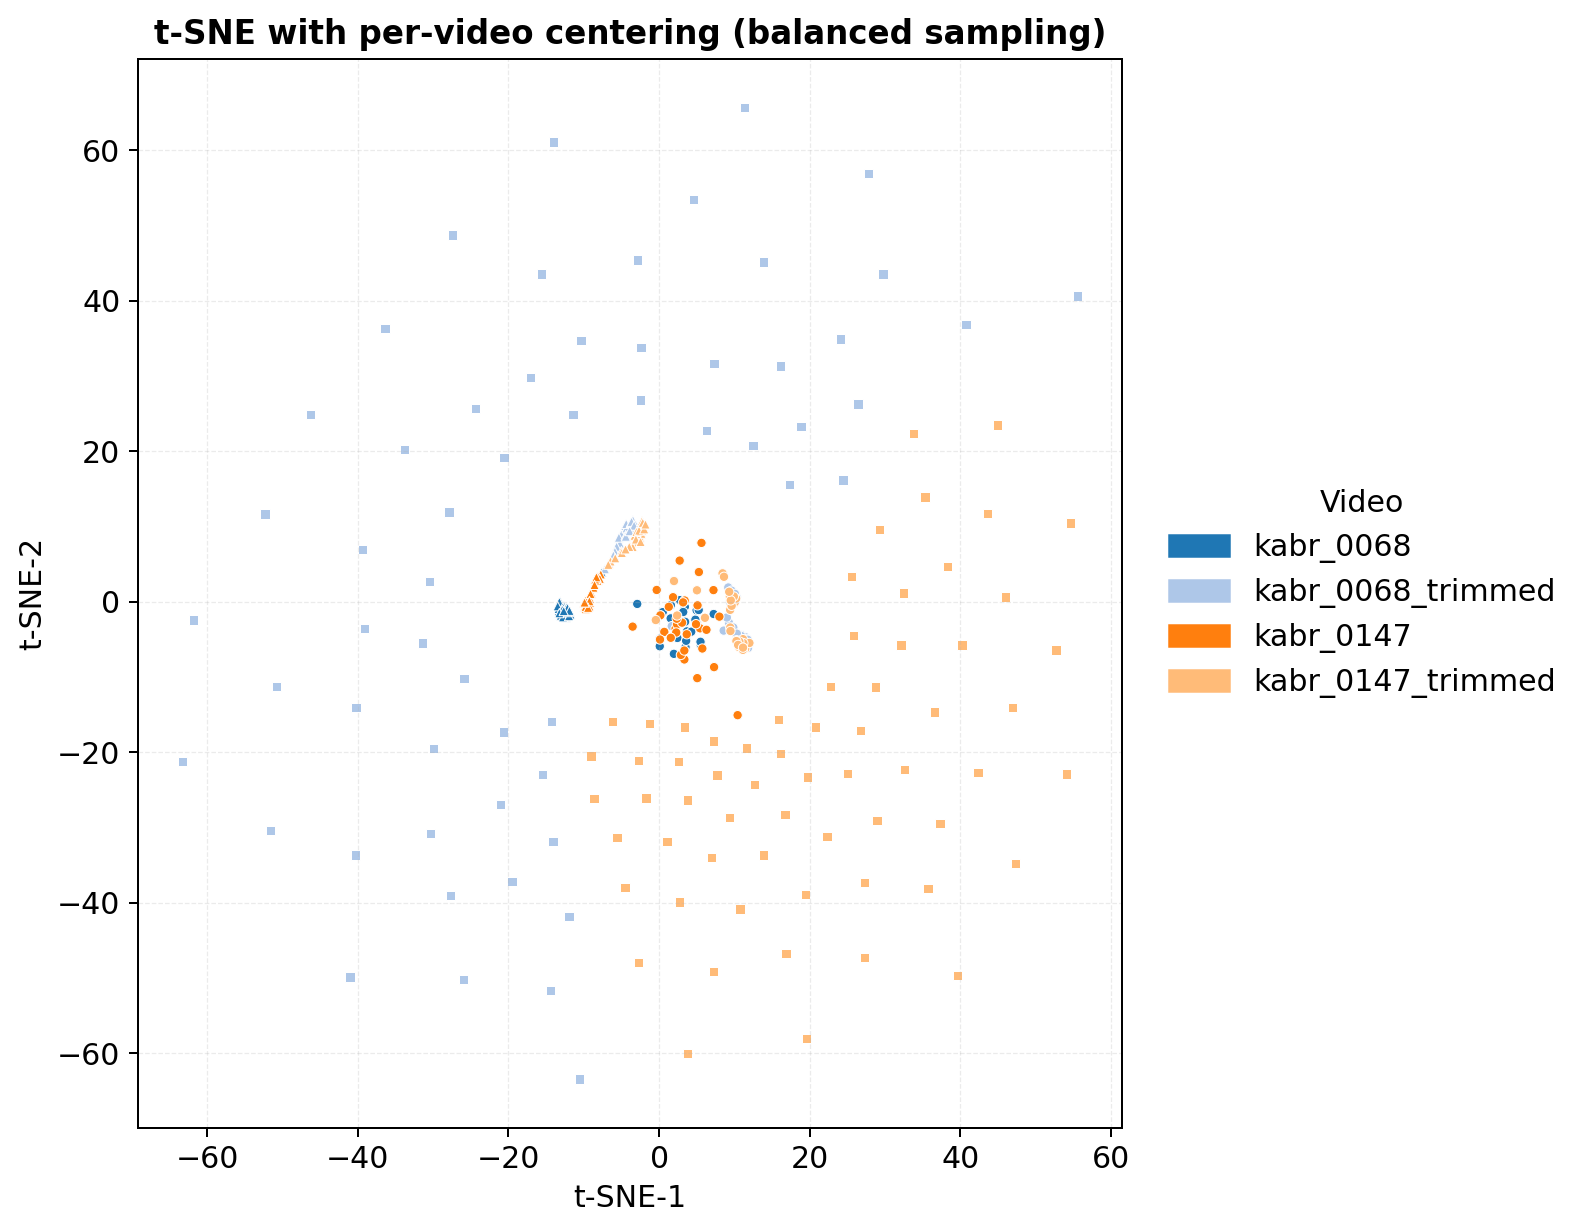

In [26]:
# ==== Re-visualize: per-video mean-centering + balanced sampling ====
import numpy as np, torch, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def l2n_np(X):
    X = np.asarray(X, np.float32)
    if X.ndim == 1: 
        n = float(np.linalg.norm(X)+1e-8); return X/n
    return X / (np.linalg.norm(X,axis=1,keepdims=True)+1e-8)

def ensure_2d_np(A):
    A = np.asarray(A); 
    return A if A.ndim==2 else A.reshape(-1, A.shape[-1])

def to_dim_np(A, D):
    A = ensure_2d_np(A); n,d = A.shape
    if d==D: return A
    if d< D: return np.concatenate([A, np.zeros((n,D-d),A.dtype)],1)
    return A[:, :D]

# 维度（沿用之前）
CLIP_D = 768

# ---- 均衡抽样并映射 ----
max_tok, max_img, max_aud = 32, 24, 64   # 适当均衡三模态
rows, vids, mods = [], [], []
for gid, v in data.items():
    # text -> CLIP
    if 'align_mapper_tok.pt' in os.listdir('./runs') and v.get("text_tok") is not None and v["text_tok"].size:
        ck = torch.load('./runs/align_mapper_tok.pt', map_location=device)
        class Mapper(torch.nn.Module):
            def __init__(self, d_in, d_out):
                super().__init__(); self.lin = torch.nn.Linear(d_in,d_out,bias=False)
            def forward(self,x):
                x = torch.as_tensor(x, dtype=torch.float32, device=device)
                if x.ndim==1: x=x.unsqueeze(0)
                out = self.lin(x); return torch.nn.functional.normalize(out,dim=-1)
        mapper_tok = Mapper(ck['in_dim'], ck['out_dim']).to(device).eval()
        mapper_tok.load_state_dict(ck['state_dict'])
        idx = np.random.choice(len(v["text_tok"]), size=min(max_tok,len(v["text_tok"])), replace=False)
        with torch.no_grad():
            zt = mapper_tok(v["text_tok"][idx]).cpu().numpy()
        rows.append(zt); vids += [gid]*len(zt); mods += ["text_token"]*len(zt)

    # image (CLIP)
    if v.get("image") is not None and v["image"].size:
        idx = np.random.choice(len(v["image"]), size=min(max_img,len(v["image"])), replace=False)
        zi = l2n_np(to_dim_np(v["image"][idx], CLIP_D))
        rows.append(zi); vids += [gid]*len(zi); mods += ["image"]*len(zi)

    # audio -> CLIP
    if 'align_mapper_aud.pt' in os.listdir('./runs') and v.get("audio") is not None and v["audio"].size:
        ck = torch.load('./runs/align_mapper_aud.pt', map_location=device)
        class Mapper(torch.nn.Module):
            def __init__(self, d_in, d_out):
                super().__init__(); self.lin = torch.nn.Linear(d_in,d_out,bias=False)
            def forward(self,x):
                x = torch.as_tensor(x, dtype=torch.float32, device=device)
                if x.ndim==1: x=x.unsqueeze(0)
                out = self.lin(x); return torch.nn.functional.normalize(out,dim=-1)
        mapper_aud = Mapper(ck['in_dim'], ck['out_dim']).to(device).eval()
        mapper_aud.load_state_dict(ck['state_dict'])
        idx = np.random.choice(len(v["audio"]), size=min(max_aud,len(v["audio"])), replace=False)
        with torch.no_grad():
            za = mapper_aud(v["audio"][idx]).cpu().numpy()
        rows.append(l2n_np(za)); vids += [gid]*len(za); mods += ["audio*"]*len(za)

X = np.vstack(rows).astype(np.float32)
N,D = X.shape

# ---- 每视频去中心化（仅用于可视化）----
uniq = list(dict.fromkeys(vids))
centers = {g: X[[i for i,v in enumerate(vids) if v==g]].mean(axis=0, keepdims=True) for g in uniq}
Xc = np.vstack([X[i] - centers[vids[i]][0] for i in range(N)]).astype(np.float32)

# ---- PCA(whiten) -> t-SNE(cosine) ----
n_pca = max(2, min(50, D, N-1))
X50 = PCA(n_components=n_pca, whiten=True, random_state=0).fit_transform(Xc)
perp = max(5, min(30, N//3))
Y = TSNE(n_components=2, metric='cosine', perplexity=perp, init='pca',
         learning_rate='auto', n_iter=2000, random_state=0).fit_transform(X50)

# ---- 画图 ----
cmap = plt.get_cmap("tab20")
colors = [cmap(uniq.index(v)%20) for v in vids]
mmap = {"text_token":"o","image":"^","audio*":"s"}
plt.figure(figsize=(9,7))
for m in ["text_token","image","audio*"]:
    idx = [i for i,mm in enumerate(mods) if mm==m]
    if not idx: continue
    plt.scatter(Y[idx,0], Y[idx,1], s=14, marker=mmap[m],
                edgecolors="white", linewidths=0.4, c=[colors[i] for i in idx], label=m)
import matplotlib.patches as mpatches
handles=[mpatches.Patch(color=cmap(i%20), label=g) for i,g in enumerate(uniq)]
plt.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02,0.5), title="Video")
plt.title("t-SNE with per-video centering (balanced sampling)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.grid(True, ls="--", lw=0.5, alpha=0.25)
plt.tight_layout(); plt.savefig("tsne_aligned_centered.png", dpi=300, bbox_inches="tight"); plt.show()
